In [1]:
!pip install kaggle

In [2]:
from google.colab import files

# This will open a dialog box for you to upload the file
print("Please upload your new kaggle.json file")
files.upload()

Please upload your new kaggle.json file


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gastonarielschvartz","key":"49256c2c0a0d147de4f9106217fb8fe6"}'}

In [3]:
# Create a directory to save the file
!mkdir -p ~/.kaggle

# Move the uploaded file to the correct directory
!mv kaggle.json ~/.kaggle/

# Assign the correct permissions to protect your key
!chmod 600 ~/.kaggle/kaggle.json

### Dataset Download

In [4]:
# Download the dataset using the Kaggle API command
!kaggle datasets download -d laotse/credit-risk-dataset

Dataset URL: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
License(s): CC0-1.0
  0% 0.00/368k [00:00<?, ?B/s]
100% 368k/368k [00:00<00:00, 48.3MB/s]


### Unzip the file

In [5]:
!unzip credit-risk-dataset.zip

Archive:  credit-risk-dataset.zip
  inflating: credit_risk_dataset.csv  


### : Load and Explore the Dataset
First, we'll import the necessary libraries and load the credit_risk_dataset.csv file into a pandas DataFrame. Then, we'll use .head() and .info() for a first inspection.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# Display the first 5 rows
print("First rows of the dataset:")
display(df.head())

# Get general information (data types, non-nulls, etc.)
print("\nGeneral information of the DataFrame:")
df.info()

First rows of the dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



General information of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 

### Analysis of Missing Values and Statistics
It's crucial to check for missing values (NaN) and how to handle them. We'll also use .describe() to get a statistical summary of the numerical columns.

In [7]:
# Count missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# There are missing values in 'person_emp_length' and 'loan_int_rate'.
# A simple strategy to start is to fill them with the median of each column.
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("\nMissing values after imputation:")
print(df.isnull().sum())


# Get descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Missing values per column:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing values after imputation:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Descriptive Statistics:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Step 3: Analysis of the Target Variable (loan_status)
Let's see how our target variable is distributed. This will tell us the default rate in the dataset and if the classes are imbalanced.

Default Rate: 21.82%
Non-Default Rate: 78.18%


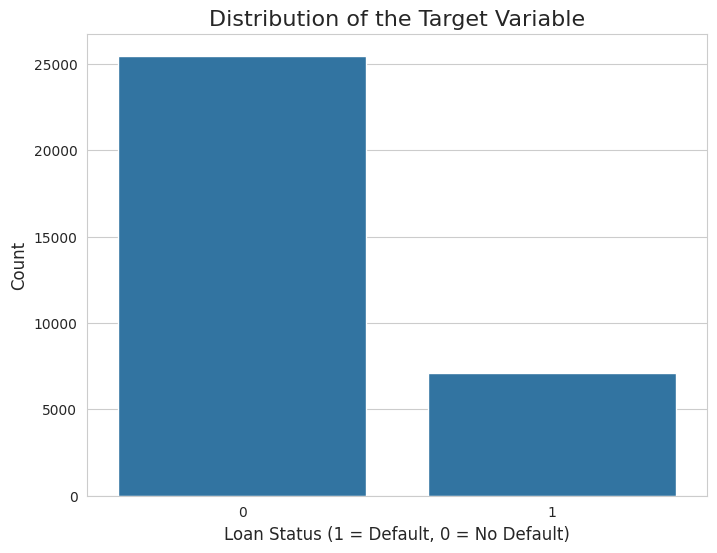

In [8]:
# Calculate the default rate
default_rate = df['loan_status'].value_counts(normalize=True) * 100
print(f"Default Rate: {default_rate[1]:.2f}%")
print(f"Non-Default Rate: {default_rate[0]:.2f}%")

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of the Target Variable', fontsize=16)
plt.xlabel('Loan Status (1 = Default, 0 = No Default)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

As we can see, there is an imbalance: approximately 21.8% of the loans in this dataset resulted in default.

### Key Visualizations
Now, let's create the visualizations you planned to answer business questions.

Default Rate by Income Level
For this, we'll first create income "brackets" and then plot the default rate for each one.

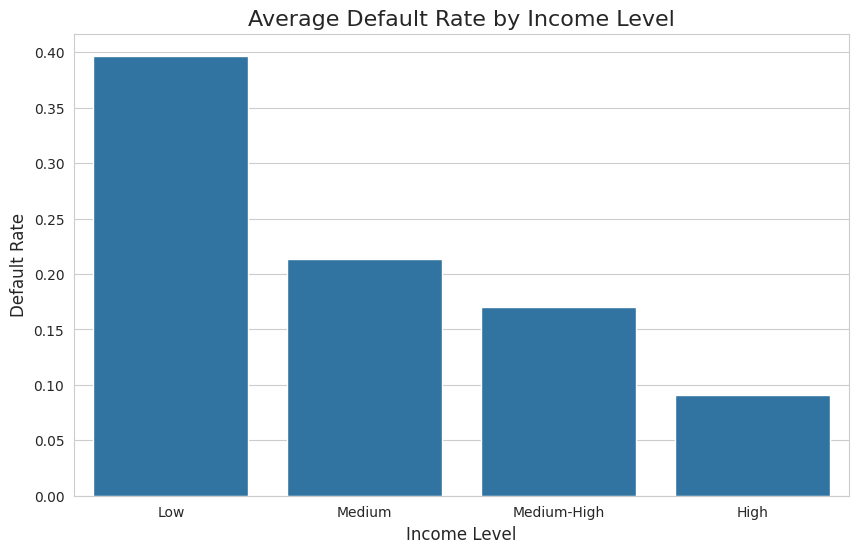

In [9]:
# Create 4 income brackets (quartiles)
df['income_bracket'] = pd.qcut(df['person_income'], q=4, labels=['Low', 'Medium', 'Medium-High', 'High'])

plt.figure(figsize=(10, 6))
sns.barplot(x='income_bracket', y='loan_status', data=df, errorbar=None)
plt.title('Average Default Rate by Income Level', fontsize=16)
plt.ylabel('Default Rate', fontsize=12)
plt.xlabel('Income Level', fontsize=12)
plt.show()

Observation: It is clear that as the income level increases, the default rate tends to decrease.

### Loan Amount Distribution by Risk
Let's compare how loan amounts are distributed for customers who paid vs. those who did not.

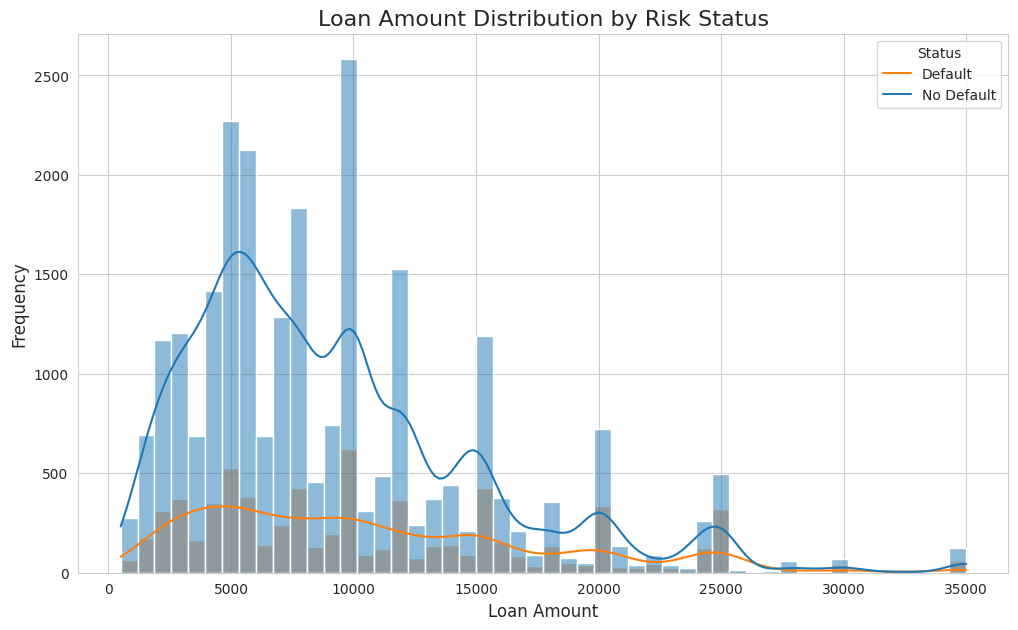

In [10]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='loan_amnt', hue='loan_status', kde=True, bins=50)
plt.title('Loan Amount Distribution by Risk Status', fontsize=16)
plt.xlabel('Loan Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Status', labels=['Default', 'No Default'])
plt.show()

**Observation:** The distributions overlap quite a bit, but the "tail" of higher loan amounts appears to have a higher proportion of defaults.

### Relationship between Age, Loan Amount, and Default
Let's see how age and loan amount relate to risk.

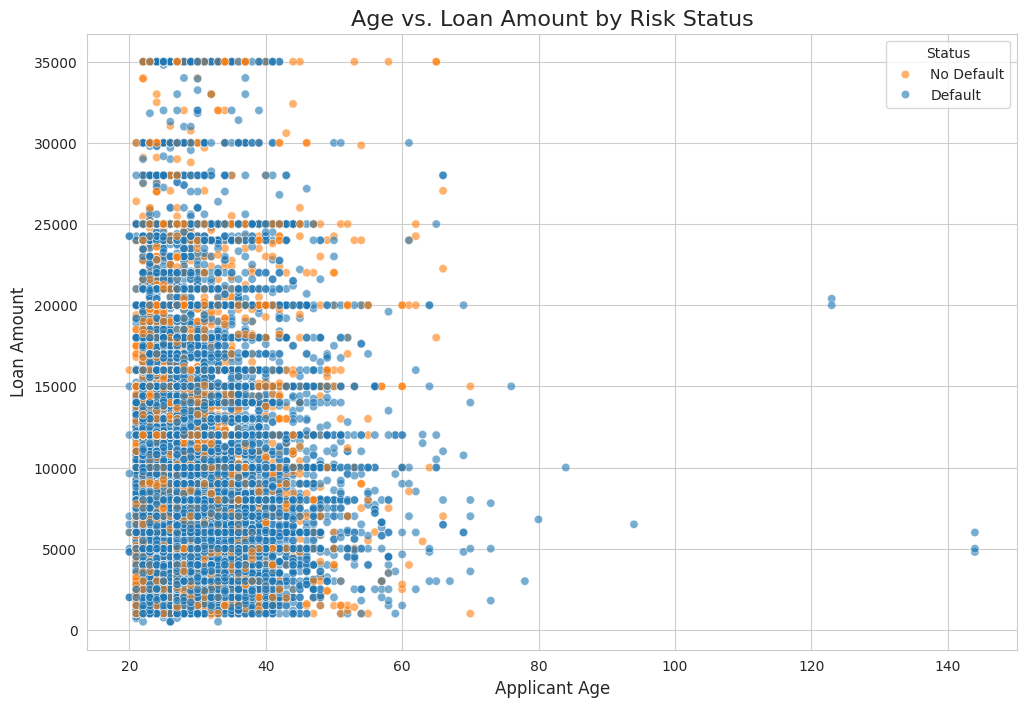

In [11]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='person_age', y='loan_amnt', hue='loan_status', alpha=0.6)
plt.title('Age vs. Loan Amount by Risk Status', fontsize=16)
plt.xlabel('Applicant Age', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Status', labels=['No Default', 'Default'])
plt.show()

**Observation:** There appears to be a concentration of defaults in younger individuals (20-30 years old) who apply for relatively high loan amounts. There are also some age outliers (greater than 100) that we might want to investigate or clean later.

## 1. Categorical Variable Encoding 📊
Mathematical models (like Logistic Regression or XGBoost) only understand numbers. We cannot give them text like "OWN" or "RENT". Therefore, we must convert all text columns into numbers.

The most common technique is One-Hot Encoding. It creates new binary columns (0 or 1) for each category.

Columns to encode: person_home_ownership, loan_intent, loan_grade, and the one we created, income_bracket.

In [12]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Apply One-Hot Encoding
# drop_first=True helps avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Original DataFrame dimensions:", df.shape)
print("Dimensions after One-Hot Encoding:", df_encoded.shape)

# See the new columns created
print("\nExample new columns:")
display(df_encoded.head())

Original DataFrame dimensions: (32581, 13)
Dimensions after One-Hot Encoding: (32581, 26)

Example new columns:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,income_bracket_Medium,income_bracket_Medium-High,income_bracket_High
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,False,True,False,False,False,True,False,True,False
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,True,False,False,False,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,False,True,False,False,False,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,False,True,False,False,False,False,False,False,True,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,False,True,False,False,False,False,True,True,False,False


## 2. Numerical Variable Scaling ⚖️
Some models are sensitive to the scale of the data. For example, an income of 80000 would have much more weight than an age of 30 simply due to the magnitude of the number. To avoid this, we put all numerical features on a comparable scale.

We will use Scikit-learn's StandardScaler, which transforms the data to have a mean of 0 and a standard deviation of 1.


In [13]:
from sklearn.preprocessing import StandardScaler

# Separate our features (X) and the target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Identify numerical columns that need to be scaled
# (Exclude those that are already 0/1 due to encoding)
numeric_cols = X.select_dtypes(include=np.number).columns
# For this example, we will scale all columns in X
# In a more advanced project, you could select only the non-binary ones

# Create the scaler object
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

# Convert it back to a DataFrame to view it
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after scaling (first 5 rows):")
display(X_scaled_df.head())

Features after scaling (first 5 rows):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,income_bracket_Medium,income_bracket_Medium-High,income_bracket_High
0,-0.903374,-0.114143,28.926614,4.019404,1.625921,3.931411,-0.691554,-0.057402,-0.293499,0.990500,...,-0.687208,-0.497207,2.825842,-0.174614,-0.086325,-0.044364,2.161294,-0.581402,1.744940,-0.577244
1,-1.060904,-0.911147,0.056763,-1.358650,0.042310,-0.657458,-0.938167,-0.057402,3.407161,-1.009591,...,1.455163,-0.497207,-0.353877,-0.174614,-0.086325,-0.044364,-0.462686,-0.581402,-0.573085,-0.577244
2,-0.430783,-0.911147,-0.921876,-0.646849,0.603713,3.744110,-0.691554,-0.057402,-0.293499,-1.009591,...,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364,-0.462686,-0.581402,-0.573085,-0.577244
3,-0.745843,-0.009274,-0.187897,4.019404,1.369558,3.369508,-0.938167,-0.057402,-0.293499,0.990500,...,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364,-0.462686,-0.581402,1.744940,-0.577244
4,-0.588313,-0.188358,0.790742,4.019404,1.058028,3.556809,-0.444942,-0.057402,-0.293499,0.990500,...,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364,2.161294,1.719979,-0.573085,-0.577244


## 3. Multicollinearity Check (Optional but Recommended) 🔗
Multicollinearity occurs when two or more features are highly correlated with each other (e.g., age and years of experience). This can make the model unstable and feature importance difficult to interpret.

A quick way to check is with a heatmap of the correlation matrix.

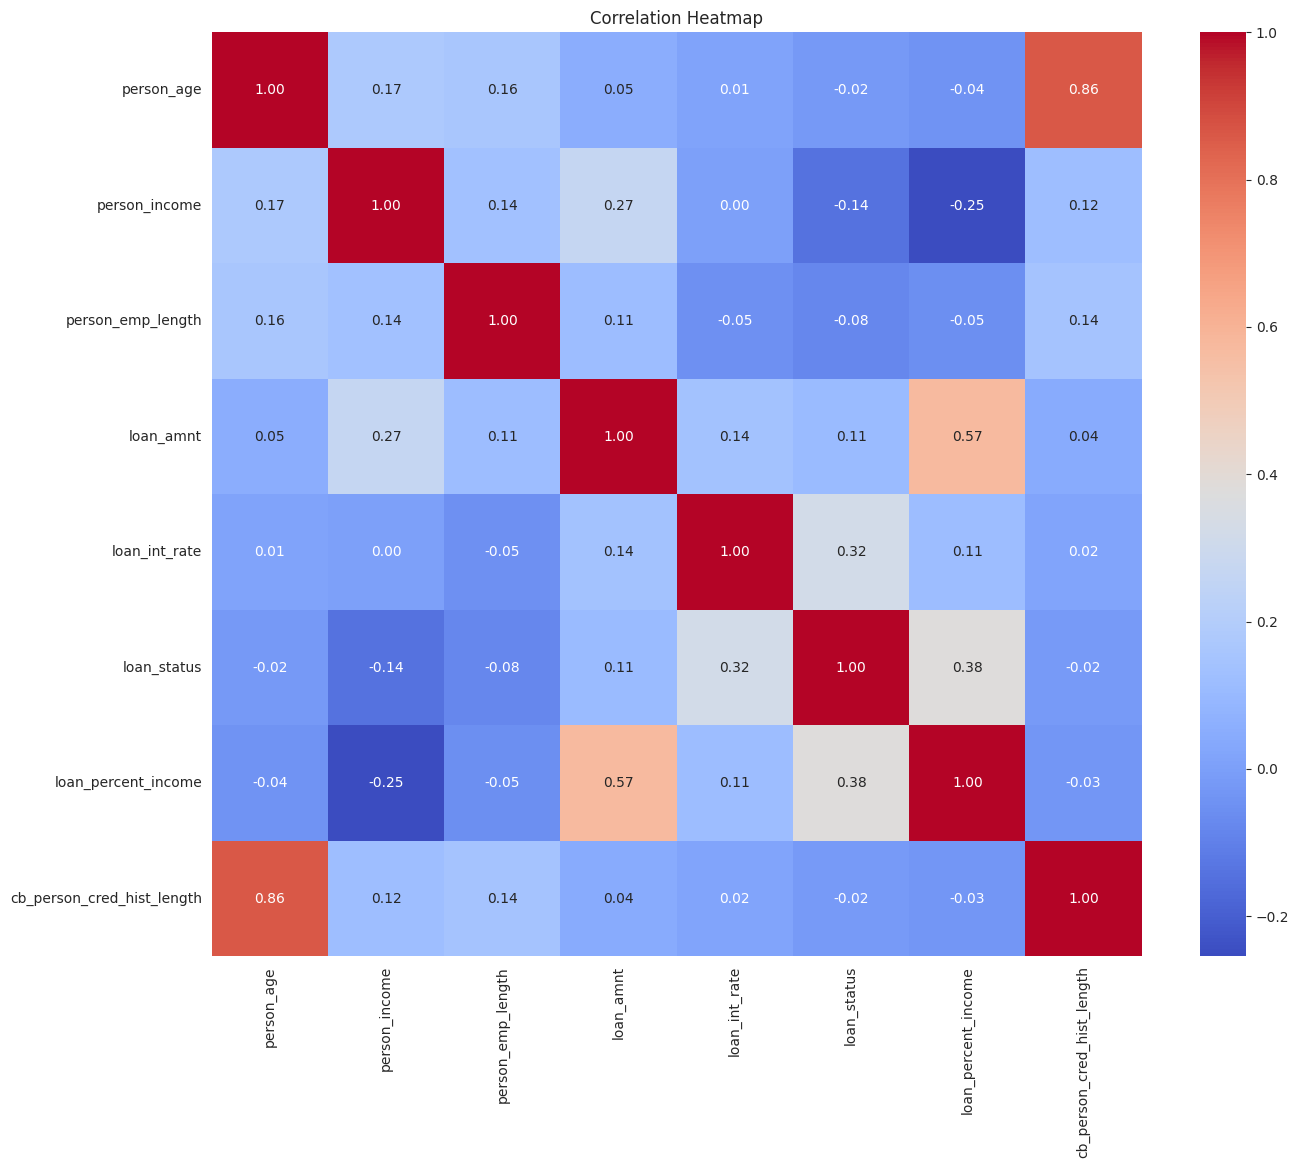

In [14]:
plt.figure(figsize=(15, 12))
correlation_matrix = df.corr(numeric_only=True) # Use the original df before encoding for simplicity
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 4. Train/Test Split 🔪
This is the golden rule. We should NEVER evaluate the model with the same data it used to learn. Therefore, we split the dataset:

Training set: The majority of the data (usually 80%) to train the model.

Test set: A smaller portion (20%) that the model has never seen, for an honest evaluation of its performance.

In [15]:
from sklearn.model_selection import train_test_split

# Split the ALREADY SCALED data
# Use stratify=y to ensure both sets have the same proportion of defaults
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Distribution of defaults in y_train:\n", y_train.value_counts(normalize=True))
print("\nDistribution of defaults in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (26064, 25)
Shape of X_test: (6517, 25)
Distribution of defaults in y_train:
 loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64

Distribution of defaults in y_test:
 loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


---

## 1. Baseline Model: Logistic Regression
This is a simple and fast model that gives us a reference point. If our advanced model doesn't significantly outperform this one, we'll know something isn't right.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Evaluate performance
print("--- Logistic Regression Results ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"AUC-ROC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

--- Logistic Regression Results ---

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      5095
           1       0.75      0.55      0.64      1422

    accuracy                           0.86      6517
   macro avg       0.82      0.75      0.78      6517
weighted avg       0.86      0.86      0.85      6517

AUC-ROC Score: 0.8705


### Confusion Matrix
The confusion matrix helps us visualize the model's hits and errors, especially how many "defaults" it predicted correctly (true positives).

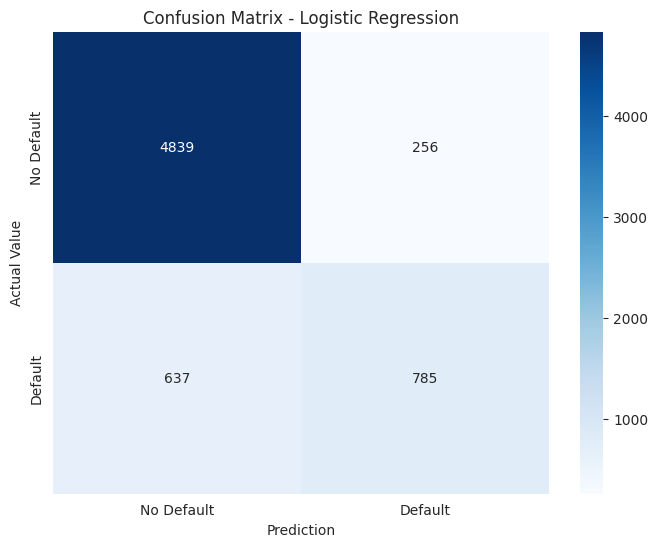

In [17]:
# Calculate the confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Visualize the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Value')
plt.xlabel('Prediction')
plt.show()

---


## 2. Main Model: XGBoost
Now, let's use XGBoost, a much more sophisticated model known for its high performance.

In [18]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost model
# The scale_pos_weight parameter helps handle class imbalance
# (Total non-defaults / Total defaults)
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    random_state=42,
    # use_label_encoder=False, # This parameter is deprecated and will be removed in a future release.
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight # Key parameter
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate performance
print("--- XGBoost Results ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print(f"AUC-ROC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

--- XGBoost Results ---

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5095
           1       0.83      0.79      0.81      1422

    accuracy                           0.92      6517
   macro avg       0.89      0.87      0.88      6517
weighted avg       0.92      0.92      0.92      6517

AUC-ROC Score: 0.9496


### Confusion Matrix
Let's compare XGBoost's errors with those of Logistic Regression.

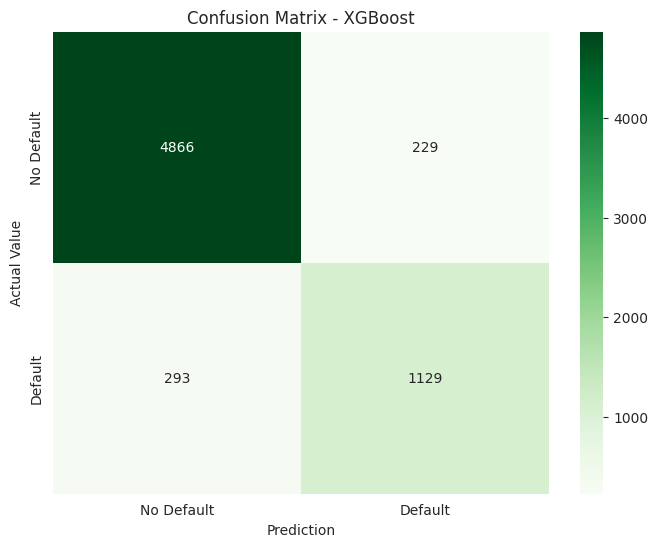

In [19]:
# Calculate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Visualize the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual Value')
plt.xlabel('Prediction')
plt.show()

---


## 3. Model Comparison with ROC Curve
The ROC curve is an excellent way to compare the overall performance of models. A model is better the closer its curve is to the upper left corner. The area under this curve is the AUC-ROC Score.

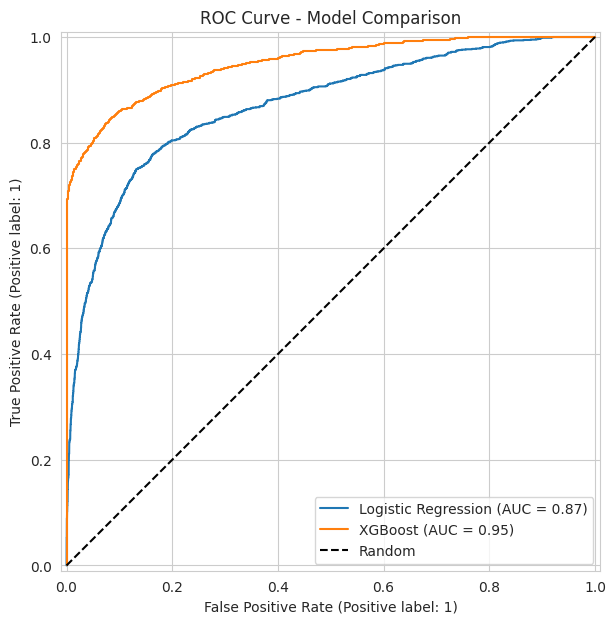

In [20]:
# Plot both ROC curves
fig, ax = plt.subplots(figsize=(10, 7))

RocCurveDisplay.from_estimator(log_reg, X_test, y_test, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name='XGBoost', ax=ax)

plt.title('ROC Curve - Model Comparison')
plt.plot([0, 1], [0, 1], 'k--', label='Random') # Reference line
plt.legend()
plt.show()

### Modeling Conclusion
As you can see from the results, the XGBoost model is significantly superior to Logistic Regression in almost all metrics, especially in the AUC-ROC Score and in its ability to correctly identify default cases (higher recall for class 1).

---

We will use the SHAP (SHapley Additive exPlanations) library to "open the black box" of our XGBoost model. SHAP will tell us exactly why the model makes a specific decision, showing the impact of each feature.

## 1. SHAP Installation and Setup
First, we make sure we have the library installed and then calculate the SHAP values for our test set.

In [21]:
!pip install shap

import shap

# 1. Create an "explainer" for our XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate the SHAP values for the test set
# This may take a few seconds
shap_values = explainer.shap_values(X_test)

## 2. Global Interpretation: What Features are Most Important?
These plots give us an overview of the model's behavior.

Feature Importance Plot
This is the simplest summary. It shows the average impact of each feature on the prediction, regardless of direction.

Feature Importance (Average Impact):


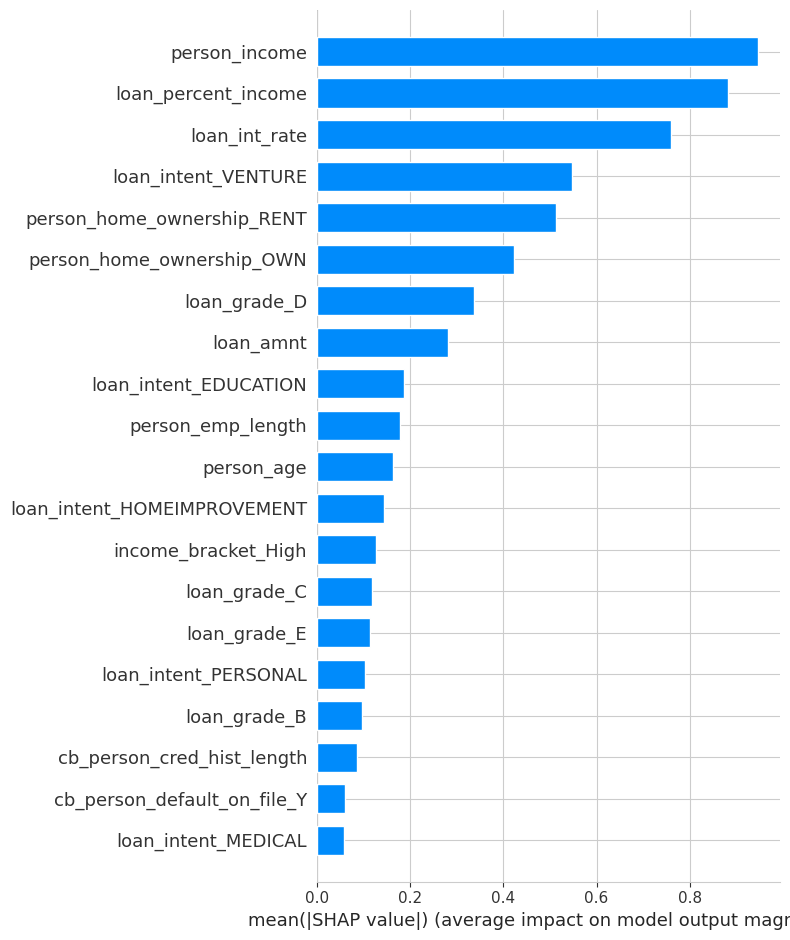

In [22]:
# Global importance bar plot
print("Feature Importance (Average Impact):")
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Insight:** This plot tells us which are the top 3-5 variables that the model considers most important overall for predicting credit risk.

### Summary Plot (Dot Plot)
This is the most powerful SHAP plot. It not only tells us which features are important but also how they affect the prediction.

Each dot is a customer in the test set.

The X-axis is the SHAP value (the impact on the prediction). Values > 0 push towards "Default".

The color represents the feature value (red = high, blue = low).


SHAP Summary Plot (Impact and Direction):


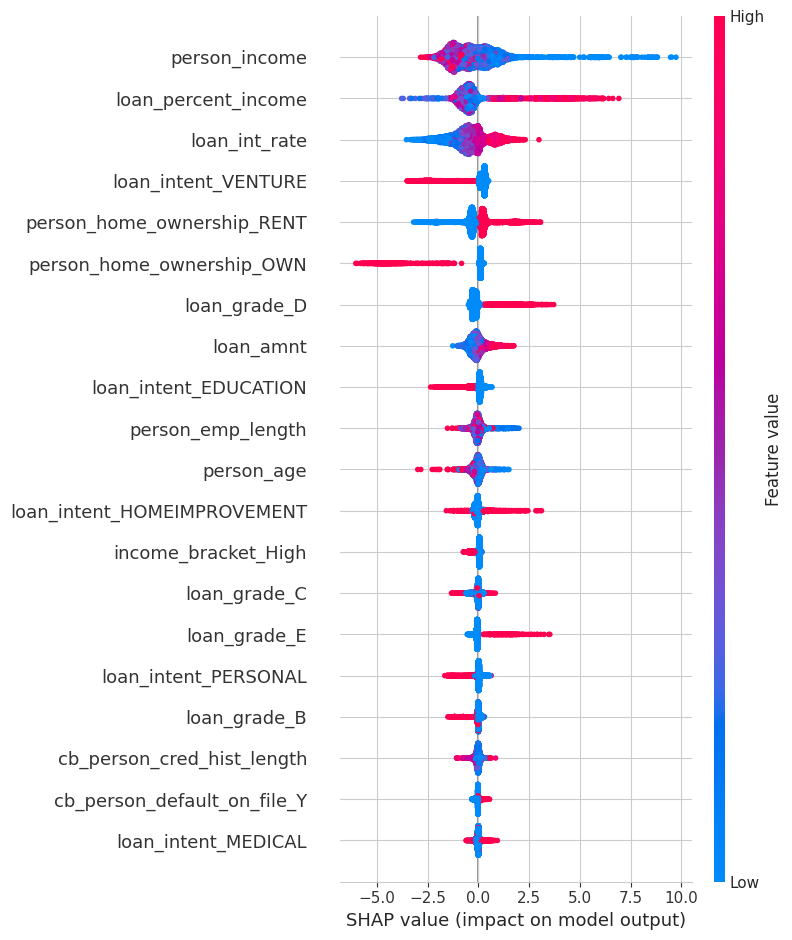

In [23]:
print("\nSHAP Summary Plot (Impact and Direction):")
shap.summary_plot(shap_values, X_test)

How to read it:

loan_int_rate (Interest Rate): Red dots (high rates) are on the right, with positive SHAP values. Conclusion: High interest rates strongly increase the probability of default.

person_income (Income): Red dots (high income) are on the left, with negative SHAP values. Conclusion: High income decreases the probability of default.

loan_grade_F/G (Loan Grade): Red dots (customers with this grade) are far to the right. Conclusion: Having a low loan grade (like F or G) is a very strong predictor of default.

---


## 3. Local Interpretation: Why Was This Customer's Credit Denied?
SHAP can also explain an individual prediction. This is extremely useful for justifying a business decision. Let's use the first customer in our test set as an example.

Waterfall Plot
Shows how each feature pushes the prediction from a base value (E[f(x)]) to the final result (f(x)).

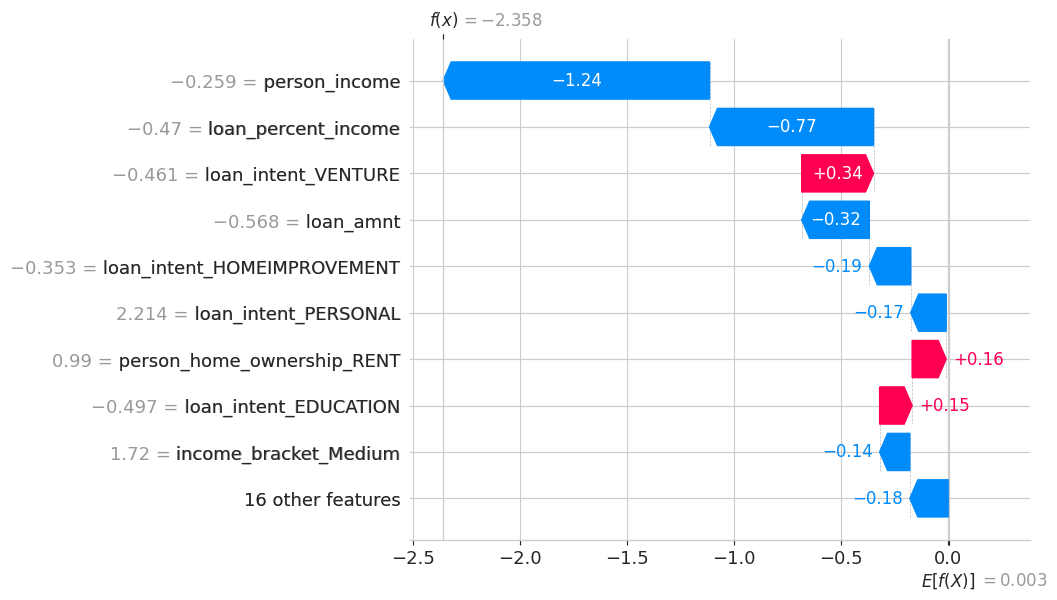

In [24]:
# -- CORRECTION --
# We choose the first observation from the test set to explain
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],          # SHAP values for this instance
    base_values=explainer.expected_value, # Base value of the explainer
    data=X_test.iloc[0],            # Data of the instance
    feature_names=X_test.columns    # Column names
))

How to read it:

The base bar (E[f(x)]) is the average prediction of the model across all data.

Red bars are features that increased the risk for this customer (pushing towards "Default").

Blue bars are features that decreased the risk.

The final bar (f(x)) is the final prediction of the model for this specific customer.


---


### Business Summary
Based on this analysis, we can extract the key findings you planned:

Top 3 default predictors: According to SHAP, the strongest predictors are consistently the interest rate (loan_int_rate), the loan grade (loan_grade), and the person's income (person_income).

Risk Patterns: The model learned logical and financially coherent rules. For example, it identifies that loans for debt consolidation (loan_intent_DEBTCONSOLIDATION) in individuals with low income and high interest rates are a very high-risk profile.

Business Impact: Thanks to interpretability, the bank can not only predict risk but also explain it. It could tell an applicant: "The main risk factor in your application is the high ratio between the loan amount and your annual income."